## 7.3 — תכונות מערך: shape, ndim, size, dtype וטיפוסים

לכל מערך NumPy יש כמה תכונות בסיסיות שכדאי לבדוק לפני שעובדים איתו:

- `a.shape` — גודל המערך בכל ציר, כטאפל. למשל `(3, 10)` — 3 שורות, 10 עמודות.
- `a.ndim` — מספר הצירים (המימד).
- `a.size` — מספר האיברים הכולל.
- `a.dtype` — טיפוס האיברים (`int64`, `float64` וכו').

`dtype` הוא לא פרט טכני שולי: מערך מטיפוס שלם (int) מעגל תוצאות של חלוקה, ופעולות עליו עלולות "לבלוע" חלקים שבריים של גדלים פיזיקליים בלי שום אזהרה.

### דוגמה: מסלולים של כמה זוויות שיגור

נבנה מערך דו-ממדי: שורה לכל זווית שיגור, עמודה לכל נקודת זמן. הגובה נתון על ידי:

$$y(t) = v_0 \sin(\theta)\, t - \tfrac{1}{2} g t^2$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

g = 9.8
v0 = 15.0
angles_deg = np.array([30, 45, 60])
t = np.linspace(0, 3, 30)

# שידור (broadcasting) של עמודה (זוויות) מול שורה (זמן) — נלמד את הכלל המדויק בשבוע 9
theta = np.radians(angles_deg)[:, None]
y = v0 * np.sin(theta) * t - 0.5 * g * t**2

print("shape:", y.shape)
print("ndim:", y.ndim)
print("size:", y.size)
print("dtype:", y.dtype)

shape: (3, 30)
ndim: 2
size: 90
dtype: float64


`y.shape` הוא `(3, 30)`: שלוש זוויות שיגור, שלושים נקודות זמן לכל אחת. נצייר את שלושת המסלולים יחד — שורה אחת של המערך מייצגת עקומה שלמה:

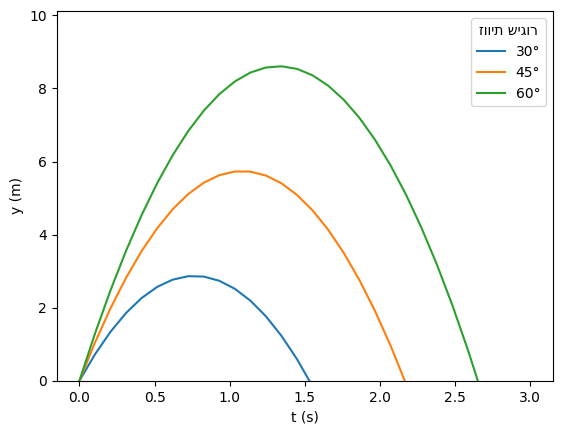

In [2]:
fig, ax = plt.subplots()
for i, ang in enumerate(angles_deg):
    ax.plot(t, y[i], label=f"{ang}°")
ax.set_xlabel("t (s)")
ax.set_ylabel("y (m)")
ax.set_ylim(bottom=0)
ax.legend(title="זווית שיגור")
plt.show()

### נסו בעצמכם

מה יהיה `shape` של המערך אם נוסיף זווית רביעית (סה"כ 4 זוויות) על פני אותם 30 זמנים? נחשו, ואז בדקו:

In [3]:
angles_deg2 = np.array([30, 45, 60, 75])
theta2 = np.radians(angles_deg2)[:, None]
y2 = v0 * np.sin(theta2) * t - 0.5 * g * t**2
# print(y2.shape)

`````{admonition} פתרון
:class: dropdown, tip
```python
print(y2.shape)   # (4, 30)
```
`````

### באג נפוץ: dtype שלם

נניח שמישהו יוצר את וקטור הזמן כך:

In [4]:
t_bug = np.array([0, 1, 2, 3])   # בלי נקודות עשרוניות!
print(t_bug.dtype)

step = t_bug[1] - t_bug[0]
half_step = step / 2   # זה בסדר — חילוק / תמיד מחזיר float
print(half_step)

t_bug[0] = 0.75   # אבל השמה למערך int מעגלת בשקט!
print(t_bug)

int64
0.5
[0 1 2 3]


השורה האחרונה היא הבאג: `t_bug` הוא מערך מטיפוס שלם, אז ההשמה `t_bug[0] = 0.75` לא זורקת שגיאה — היא פשוט חותכת ל-0, בלי אזהרה. הפתרון: לבנות את המערך מראש עם `dtype=float`, או פשוט לכתוב את הערכים כ-`0.0, 1.0, 2.0` וכו'.

### בדקו את עצמכם

In [5]:
from jupyterquiz import display_quiz

questions = [
    {
        "question": "מערך <code>a</code> נוצר עם <code>np.array([1, 2, 3])</code> (בלי נקודה עשרונית). מה יקרה בעקבות <code>a[0] = 2.7</code>?",
        "type": "multiple_choice",
        "answers": [
            {"answer": "תיזרק שגיאה, כי 2.7 אינו שלם", "correct": False, "feedback": "לא — NumPy לא בודק זאת אוטומטית."},
            {"answer": "a[0] יהפוך ל-2, בלי אזהרה", "correct": True, "feedback": "נכון. מערך int חותך ערכים שבריים בשקט בזמן ההשמה."},
            {"answer": "כל המערך יהפוך אוטומטית לטיפוס float", "correct": False, "feedback": "לא — הטיפוס של המערך נקבע ביצירה ולא משתנה בהשמה בודדת."}
        ]
    }
]

display_quiz(questions)

<IPython.core.display.Javascript object>

### תרגול עצמי

הקוד הבא נועד לחשב מחצית מכל ערך במערך זמנים, אך יש בו את אותו באג שראינו למעלה. אתרו ותקנו:

In [6]:
t_meas = np.array([0, 1, 2, 3, 4])   # זמני מדידה, בשניות
t_meas[2] = 2.5   # רוצים לתקן מדידה בודדת
# print(t_meas)   # מה יודפס, ולמה זו בעיה?

# תקנו כאן:
# t_meas_fixed = ...


`````{admonition} פתרון
:class: dropdown, tip
```python
# הבאג: t_meas נוצר כמערך int, ולכן t_meas[2] = 2.5 מתעגל ל-2.
t_meas_fixed = np.array([0, 1, 2, 3, 4], dtype=float)
t_meas_fixed[2] = 2.5
print(t_meas_fixed)
```
`````